In [ ]:
pip install --upgrade tensorflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import os

train_dir = 'drive/MyDrive/COELEGYNE'
print("Train dir exists:", os.path.exists(train_dir))
print("Classes:", os.listdir(train_dir))

for root, dirs, files in os.walk(train_dir):
    print(f"Folder: {root}, Files: {len(files)}")


Train dir exists: True
Classes: ['Coelogyne celebensis', 'Coelogyne speciosa', 'Coelogyne swaniana', 'Coelogyne miniata', 'Coelogyne pandurata', 'Coelogyne mayeriana', 'Coelogyne pulverula', 'Coelogyne asperata', 'Coelogyne fostermanii', 'Coelogyne multiflora', 'Coelegyne flexuosa']
Folder: drive/MyDrive/COELEGYNE, Files: 0
Folder: drive/MyDrive/COELEGYNE/Coelogyne celebensis, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne speciosa, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne swaniana, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne miniata, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne pandurata, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne mayeriana, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne pulverula, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne asperata, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne fostermanii, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelogyne multiflora, Files: 80
Folder: drive/MyDrive/COELEGYNE/Coelegyne fle

Found 880 images belonging to 11 classes.
Found 110 images belonging to 11 classes.
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 205s 7s/step - accuracy: 0.1255 - loss: 2.7990 - val_accuracy: 0.0909 - val_loss: 2.5918
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 192s 7s/step - accuracy: 0.2620 - loss: 2.0747 - val_accuracy: 0.1000 - val_loss: 4.0193
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 190s 7s/step - accuracy: 0.2987 - loss: 1.8432 - val_accuracy: 0.2727 - val_loss: 3.9568
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 190s 7s/step - accuracy: 0.3940 - loss: 1.6248 - val_accuracy: 0.2273 - val_loss: 4.3579
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 190s 7s/step - accuracy: 0.4148 - loss: 1.5451 - val_accuracy: 0.3000 - val_loss: 3.4774
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 186s 7s/step - accuracy: 0.4255 - loss: 1.5206 - val_accuracy: 0.2909 - val_loss: 4.1936
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.1509 - loss: 2.4551
Validation Loss: 2.5918
Validation Accuracy: 0.0909


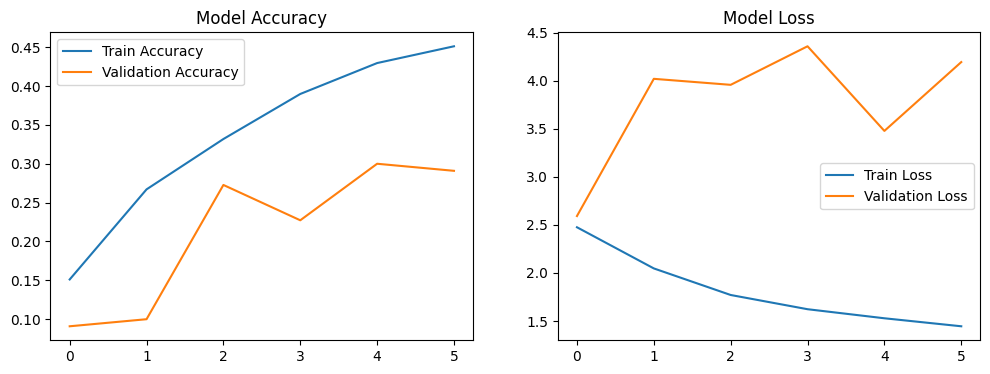

In [ ]:
train_dir = 'drive/MyDrive/COELEGYNE'
validasi_dir = 'drive/MyDrive/COE_Validasi'

# Data augmentation & rescaling for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling only for validation
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Load validation data
val_generator = val_datagen.flow_from_directory(
    validasi_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping]
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# **Testing img**

Saving 15.JPG to 15.JPG

Testing on image: 15.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Class probabilities:
Coelegyne flexuosa: 0.97%
Coelogyne asperata: 39.09%
Coelogyne celebensis: 11.02%
Coelogyne fostermanii: 7.87%
Coelogyne mayeriana: 1.99%
Coelogyne miniata: 1.67%
Coelogyne multiflora: 8.44%
Coelogyne pandurata: 14.59%
Coelogyne pulverula: 2.34%
Coelogyne speciosa: 7.37%
Coelogyne swaniana: 4.66%


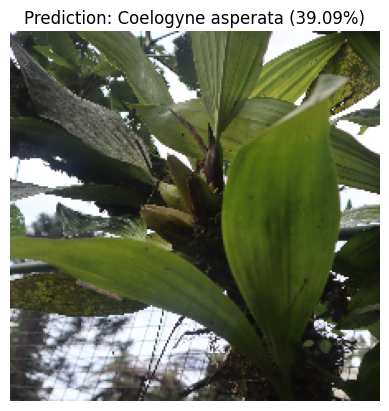

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Fungsi untuk menguji model dengan gambar baru
def predict_image(model, img_path, class_indices):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    class_labels = dict((v, k) for k, v in class_indices.items())

    # Menampilkan semua kelas dan persentasenya
    print("Class probabilities:")
    for i, prob in enumerate(predictions):
        print(f"{class_labels[i]}: {prob * 100:.2f}%")

    # Prediksi kelas tertinggi
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Menampilkan gambar dengan prediksi
    plt.imshow(img)
    plt.title(f'Prediction: {predicted_class} ({confidence:.2f}%)')
    plt.axis('off')
    plt.show()

uploaded = files.upload()

for img_name in uploaded.keys():
    print(f"\nTesting on image: {img_name}")
    predict_image(model, img_name, train_generator.class_indices)


# **Simpan model**

In [ ]:
model.save('coelogyne_model.keras')

model.save('coelogyne_model.h5')

print("Model telah dilatih dan disimpan!")


# **Simpan Mode ke files**

In [ ]:
from google.colab import files
model.save('coelogyne_model.keras')
files.download('coelogyne_model.keras')
